In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [3]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/codespace/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [4]:
from wordcloud import WordCloud
import joblib

#### Loading the dataset

In [5]:
df = pd.read_csv("combined_data.csv")
df

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...
...,...,...
83443,0,hi given a date how do i get the last date of ...
83444,1,now you can order software on cd or download i...
83445,1,dear valued member canadianpharmacy provides a...
83446,0,subscribe change profile contact us long term ...


In [6]:
df = df[['label', 'text']]  # Keep only the important columns
df.columns = ['label', 'message']  # Rename columns

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(df.head())

Dataset loaded successfully!
Shape: (83448, 2)
   label                                            message
0      1  ounce feather bowl hummingbird opec moment ala...
1      1  wulvob get your medircations online qnb ikud v...
2      0   computer connection from cnn com wednesday es...
3      1  university degree obtain a prosperous future m...
4      0  thanks for all your answers guys i know i shou...


#### Explore the data

In [7]:
# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
label      0
message    0
dtype: int64


In [8]:
# Check for duplicates
print(f"\nDuplicate messages: {df.duplicated('message').sum()}")
df = df.drop_duplicates('message')  # Remove duplicates
print(f"Shape after removing duplicates: {df.shape}")


Duplicate messages: 2
Shape after removing duplicates: (83446, 2)


In [9]:
# Class distribution
print("\nClass Distribution:")
print(df['label'].value_counts())


Class Distribution:
label
1    43908
0    39538
Name: count, dtype: int64


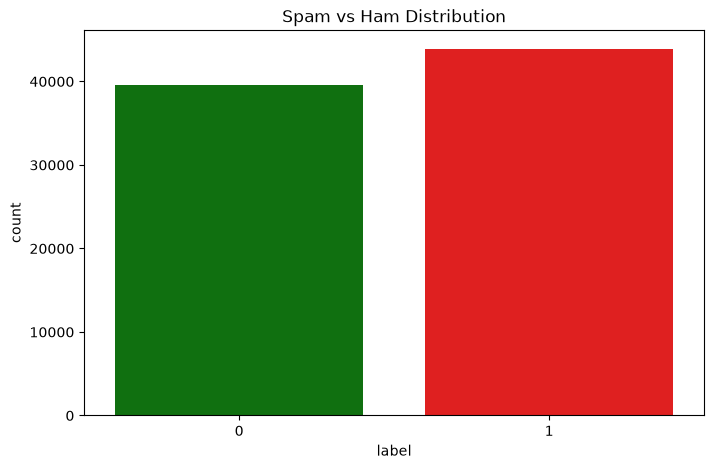

In [10]:
# Visualize class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, palette=['green', 'red'])
plt.title('Spam vs Ham Distribution')
plt.show()

In [11]:
# Add message length column
df['length'] = df['message'].apply(len)

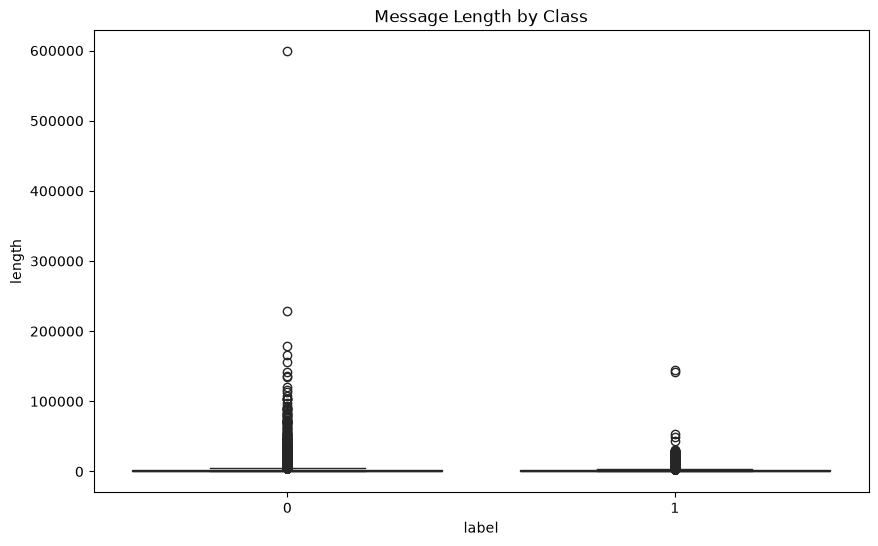

In [12]:
# Visualize message length by class
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='length', data=df, palette=['green', 'red'])
plt.title('Message Length by Class')
plt.show()

#### Text Preprocessing

In [13]:
# Initialize stemmer and stopwords
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))


In [14]:
def clean_text(text):
    """Clean and preprocess text"""
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [15]:
def tokenize_and_stem(text):
    """Tokenize and apply stemming"""
    # Split into words
    words = text.split()
    
    # Remove stopwords and apply stemming
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    
    return ' '.join(words)

In [16]:
# Apply preprocessing
print("Preprocessing messages...")
df['cleaned_message'] = df['message'].apply(clean_text)
df['processed_message'] = df['cleaned_message'].apply(tokenize_and_stem)

print("\nBefore preprocessing:")
print(df['message'].iloc[0])
print("\nAfter preprocessing:")
print(df['processed_message'].iloc[0])

Preprocessing messages...

Before preprocessing:
ounce feather bowl hummingbird opec moment alabaster valkyrie dyad bread flack desperate iambic hadron heft quell yoghurt bunkmate divert afterimage

After preprocessing:
ounc feather bowl hummingbird opec moment alabast valkyri dyad bread flack desper iambic hadron heft quell yoghurt bunkmat divert afterimag


#### Exploratory Data Analysis (EDA)

In [17]:
# Word cloud for spam messages
spam_text = ' '.join(df[df['label']=='spam']['cleaned_message'])

In [18]:
# Check if there are words to generate word cloud
if spam_text.strip():  # Check if not empty
    wordcloud = WordCloud(width=800, height=400, background_color='white', 
                          colormap='Reds', max_words=100).generate(spam_text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title('Most Common Words in Spam Emails', fontsize=16)
    plt.axis('off')
    plt.show()
else:
    print("⚠️ No words found in spam messages to generate word cloud")

⚠️ No words found in spam messages to generate word cloud


In [19]:
# Word cloud for ham messages
ham_text = ' '.join(df[df['label']=='ham']['cleaned_message'])

if ham_text.strip():  # Check if not empty
    wordcloud = WordCloud(width=800, height=400, background_color='white', 
                          colormap='Greens', max_words=100).generate(ham_text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title('Most Common Words in Ham Emails', fontsize=16)
    plt.axis('off')
    plt.show()
else:
    print("⚠️ No words found in ham messages to generate word cloud")

⚠️ No words found in ham messages to generate word cloud


#### Feature Extraction

In [20]:
# First, let's check what's in the label column
print("Unique values in label column:")
print(df['label'].unique())
print(f"Data type: {df['label'].dtype}")
print(f"Null values: {df['label'].isnull().sum()}")

Unique values in label column:
[1 0]
Data type: int64
Null values: 0


In [21]:
# Clean up labels - remove any whitespace and convert to lowercase
df['label'] = df['label'].astype(str).str.strip().str.lower()

# Show label distribution after cleaning
print("After cleaning label distributions:")
print(df['label'].value_counts())


After cleaning label distributions:
label
1    43908
0    39538
Name: count, dtype: int64


In [22]:
# Determine label mapping based on the actual data values
unique_labels = set(df['label'].unique())
print(f"Unique labels after cleaning: {unique_labels}")

if unique_labels <= {'ham', 'spam'}:
    label_mapping = {'ham': 0, 'spam': 1}
    df['label_encoded'] = df['label'].map(label_mapping)
elif unique_labels <= {'0', '1'}:
    df['label_encoded'] = df['label'].astype(int)
else:
    raise ValueError(f'Unexpected label values: {unique_labels}')


Unique labels after cleaning: {'0', '1'}


In [23]:
# Remove rows with labels that could not be mapped
nan_count = df['label_encoded'].isnull().sum()
print(f"NaN values in encoded labels: {nan_count}")
if nan_count > 0:
    print("Warning: Some labels couldn't be mapped. Check for unexpected values.")
    print(df[df['label_encoded'].isnull()]['label'].unique())
    df = df.dropna(subset=['label_encoded'])

print(f"Shape after removing NaN labels: {df.shape}")


NaN values in encoded labels: 0
Shape after removing NaN labels: (83446, 6)


In [24]:
# Verify label encoding is correct and prepare features
print(df[['label', 'label_encoded']].head())
print('Remaining rows:', len(df))

X = df['processed_message']  # or use 'message' if not preprocessed
y = df['label_encoded']  # This should now be 0 (ham) and 1 (spam)

print(f"Final y shape: {len(y)}")
print(f"y value counts: {y.value_counts()}")
print(f"Any NaN in y: {y.isnull().any()}")


  label  label_encoded
0     1              1
1     1              1
2     0              0
3     1              1
4     0              0
Remaining rows: 83446
Final y shape: 83446
y value counts: label_encoded
1    43908
0    39538
Name: count, dtype: int64
Any NaN in y: False


In [25]:
# Check for any NaN values in encoded column
print(f"\nNaN values in encoded labels: {df['label_encoded'].isnull().sum()}")
if df['label_encoded'].isnull().sum() > 0:
    print("Warning: Some labels couldn't be mapped. Check for unexpected values.")
    print(df[df['label_encoded'].isnull()]['label'].unique())


NaN values in encoded labels: 0


In [26]:
# Remove any rows with NaN labels
df = df.dropna(subset=['label_encoded'])
print(f"Shape after removing NaN labels: {df.shape}")

Shape after removing NaN labels: (83446, 6)


In [27]:
# The labels have already been mapped from 'ham'/'spam' to 0/1 above.
# No further casting is required for this dataset.
# If your dataset already contains numeric labels '0' and '1', use this instead:
# df['label_encoded'] = df['label'].astype(int)

In [28]:
# No additional filtering is needed after label cleaning and mapping.
# Keep all valid rows in the dataset.

In [29]:
# Verify label encoding is correct.
print(df[['label', 'label_encoded']].head())
print("Remaining rows:", len(df))

  label  label_encoded
0     1              1
1     1              1
2     0              0
3     1              1
4     0              0
Remaining rows: 83446


In [30]:
# Prepare features
X = df['processed_message']  # or use 'message' if not preprocessed
y = df['label_encoded']  # This should now be 0 (ham) and 1 (spam)

In [31]:
# Verify y has no NaN values
print(f"\nFinal y shape: {len(y)}")
print(f"y value counts: {y.value_counts()}")
print(f"Any NaN in y: {y.isnull().any()}")
print(f"y sample: {y.head(10)}")


Final y shape: 83446
y value counts: label_encoded
1    43908
0    39538
Name: count, dtype: int64
Any NaN in y: False
y sample: 0    1
1    1
2    0
3    1
4    0
5    0
6    0
7    0
8    1
9    1
Name: label_encoded, dtype: int64


In [32]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print(f"Training set class distribution:\n{y_train.value_counts()}")
print(f"Testing set class distribution:\n{y_test.value_counts()}")


Training set size: 66756
Testing set size: 16690
Training set class distribution:
label_encoded
1    35126
0    31630
Name: count, dtype: int64
Testing set class distribution:
label_encoded
1    8782
0    7908
Name: count, dtype: int64


In [33]:
# Apply TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"\nTF-IDF shape: {X_train_tfidf.shape}")


TF-IDF shape: (66756, 5000)


#### Multi-Model Training

In [34]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='linear', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

print("\n" + "="*50)
print("TRAINING AND EVALUATING MODELS")
print("="*50)


TRAINING AND EVALUATING MODELS


In [35]:
for name, model in models.items():
    # Train
    model.fit(X_train_tfidf, y_train)
    
    # Predict
    y_pred = model.predict(X_test_tfidf)
    
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Model': model
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")


Naive Bayes:
  Accuracy:  0.9673
  Precision: 0.9675
  Recall:    0.9704
  F1-Score:  0.9690



Logistic Regression:
  Accuracy:  0.9838
  Precision: 0.9810
  Recall:    0.9884
  F1-Score:  0.9847

SVM:
  Accuracy:  0.9858
  Precision: 0.9824
  Recall:    0.9908
  F1-Score:  0.9866

Random Forest:
  Accuracy:  0.9853
  Precision: 0.9849
  Recall:    0.9872
  F1-Score:  0.9861


#### Compare Results

In [36]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    name: [results[name]['Accuracy'], 
           results[name]['Precision'], 
           results[name]['Recall'], 
           results[name]['F1-Score']]
    for name in results.keys()
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(comparison_df)


MODEL COMPARISON
           Naive Bayes  Logistic Regression       SVM  Random Forest
Accuracy      0.967286             0.983823  0.985800       0.985321
Precision     0.967530             0.981013  0.982387       0.984892
Recall        0.970394             0.988385  0.990777       0.987247
F1-Score      0.968960             0.984685  0.986564       0.986068


<Figure size 1200x600 with 0 Axes>

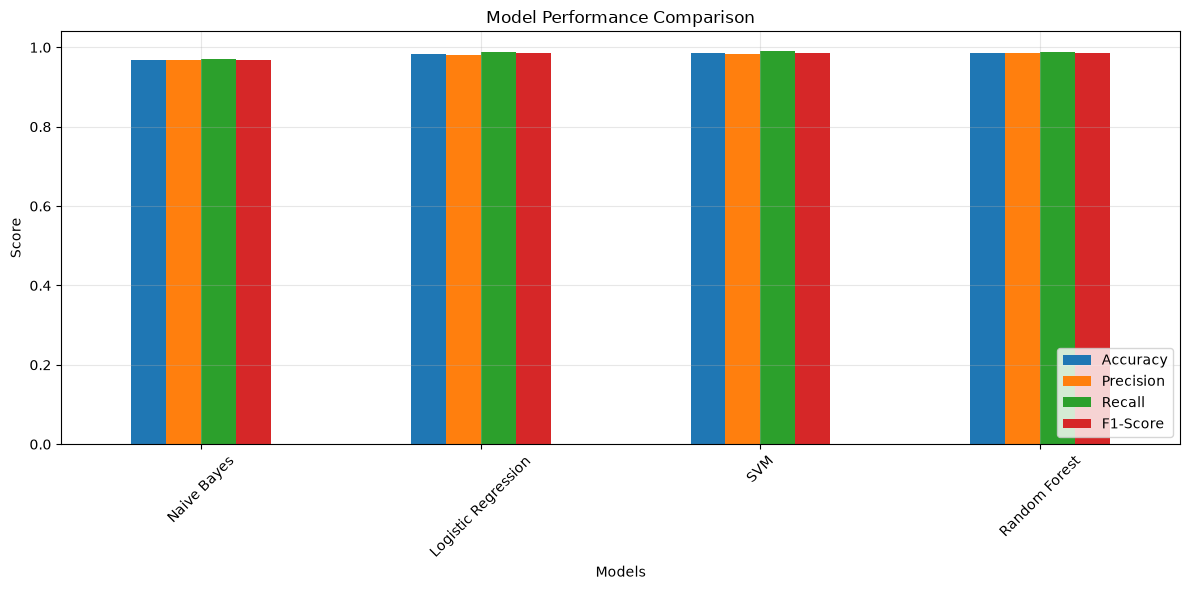

In [37]:
# Visualize comparison
plt.figure(figsize=(12, 6))
comparison_df.T.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Confusion Matrix for Best Model

In [38]:
# Find best model based on F1-score
best_model_name = max(results, key=lambda x: results[x]['F1-Score'])
best_model = results[best_model_name]['Model']

print(f"\nBest model: {best_model_name}")
print(f"F1-Score: {results[best_model_name]['F1-Score']:.4f}")


Best model: SVM
F1-Score: 0.9866


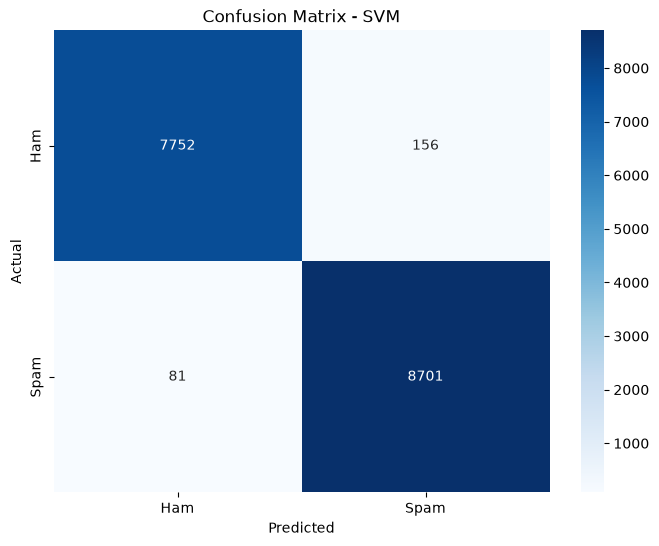

In [39]:
# Confusion matrix
y_pred_best = best_model.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], 
            yticklabels=['Ham', 'Spam'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [40]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Ham', 'Spam']))


Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.98      7908
        Spam       0.98      0.99      0.99      8782

    accuracy                           0.99     16690
   macro avg       0.99      0.99      0.99     16690
weighted avg       0.99      0.99      0.99     16690



#### Hyperparameter Tuning (Optional)

In [42]:
# Tune the best model
if best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.1, 1, 10],
        'solver': ['liblinear', 'saga']
    }
    grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), 
                        param_grid, cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train_tfidf, y_train)
    
    print(f"Best parameters: {grid.best_params_}")
    print(f"Best F1-score: {grid.best_score_:.4f}")

    # Use tuned model
    best_model_tuned = grid.best_estimator_
    y_pred_tuned = best_model_tuned.predict(X_test_tfidf)
    f1_tuned = f1_score(y_test, y_pred_tuned)
    print(f"Test F1-score with tuning: {f1_tuned:.4f}")

#### Save The Model

In [43]:
# Save the model and vectorizer
joblib.dump(best_model, 'spam_detector_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("\n✅ Model and vectorizer saved successfully!")
print("Files: spam_detector_model.pkl, tfidf_vectorizer.pkl")


✅ Model and vectorizer saved successfully!
Files: spam_detector_model.pkl, tfidf_vectorizer.pkl


#### Create Prediction Function

In [44]:
def predict_spam(email_text):
    """
    Predict if an email is spam or ham
    
    Parameters:
    email_text (str): The email content to classify
    
    Returns:
    str: 'Spam' or 'Ham'
    float: Confidence score
    """
    # Load model and vectorizer
    model = joblib.load('spam_detector_model.pkl')
    vectorizer = joblib.load('tfidf_vectorizer.pkl')
    
    # Preprocess
    cleaned = clean_text(email_text)
    processed = tokenize_and_stem(cleaned)
    
    # Vectorize
    vectorized = vectorizer.transform([processed])
    
    # Predict
    prediction = model.predict(vectorized)[0]
    confidence = model.predict_proba(vectorized)[0][1] if hasattr(model, 'predict_proba') else None
    
    label = 'Spam' if prediction == 1 else 'Ham'
    
    if confidence is not None:
        return label, confidence
    return label

In [45]:
# Test the function
test_emails = [
    "Congratulations! You've won a free iPhone. Click here to claim your prize!",
    "Hey, are we still meeting for lunch tomorrow? Let me know.",
    "URGENT: Your bank account has been compromised. Verify your details now.",
    "The project report is attached. Please review it before the meeting."
]

print("\n" + "="*50)
print("TESTING PREDICTION FUNCTION")
print("="*50)

for email in test_emails:
    result = predict_spam(email)
    print(f"\nEmail: {email[:50]}...")
    print(f"Prediction: {result}")


TESTING PREDICTION FUNCTION

Email: Congratulations! You've won a free iPhone. Click h...
Prediction: Spam

Email: Hey, are we still meeting for lunch tomorrow? Let ...
Prediction: Ham

Email: URGENT: Your bank account has been compromised. Ve...
Prediction: Spam

Email: The project report is attached. Please review it b...
Prediction: Ham
